## Choose Your Own Hypothesis Project: Detection Method and Insolation Flux in Exoplanets

### Research Question

Does discovery method influence the insolation flux of detected exoplanets? If so, are our catalogs of potentially Earth-like worlds shaped by search technique rather than true planetary distribution?

### Hypothesis

- **H₀ (Null):** Discovery method has no influence on insolation flux. The mean insolation flux of planets found by the Transit method equals that of planets found by the Radial Velocity method. Any observed difference is due to random chance.
- **H₁ (Alternative):** Discovery method does influence insolation flux. The mean insolation flux of Transit-detected planets differs from that of Radial Velocity-detected planets.


### Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_file_name = "data/PS_2026.05.02_07.24.36.csv"
planets = pd.read_csv(data_file_name, comment="#", low_memory=False)

### Exploratory Data Analysis


In [3]:
display(planets.shape)
display(planets.describe())

(39816, 289)

,rowid,default_flag,sy_snum,sy_pnum,sy_mnum,cb_flag,disc_year,rv_flag,pul_flag,ptv_flag,...,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
count,39816.000000,39816.000000,39816.000000,39816.000000,39816.0,39816.000000,39814.000000,39794.000000,39794.000000,39794.000000,...,31190.000000,0.0,0.0,39765.000000,39765.000000,39765.000000,39765.000000,39765.000000,39765.000000,39765.000000
mean,19908.500000,0.157675,1.085895,1.916164,0.0,0.002436,2015.631059,0.254536,0.000327,0.000050,...,14.109630,NaN,NaN,1.024947,0.470539,0.200402,0.115277,0.257538,0.222910,0.007896
std,11494.033496,0.364441,0.311536,1.237411,0.0,0.049298,4.131007,0.435605,0.018072,0.007089,...,1.442692,NaN,NaN,1.133961,3.789843,0.904726,0.800135,1.914948,1.627492,0.219825
min,1.000000,0.000000,1.000000,1.000000,0.0,0.000000,1992.000000,0.000000,0.000000,0.000000,...,5.973000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9954.750000,0.000000,1.000000,1.000000,0.0,0.000000,2014.000000,0.000000,0.000000,0.000000,...,13.352000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,19908.500000,0.000000,1.000000,1.000000,0.0,0.000000,2016.000000,0.000000,0.000000,0.000000,...,14.415000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,29862.250000,0.000000,1.000000,2.000000,0.0,0.000000,2016.000000,1.000000,0.000000,0.000000,...,15.212000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,39816.000000,1.000000,4.000000,8.000000,0.0,1.000000,2026.000000,1.000000,1.000000,1.000000,...,17.475000,NaN,NaN,16.000000,70.000000,12.000000,13.000000,35.000000,32.000000,10.000000


In [4]:
# display(planets["discoverymethod"].unique())
display(planets["discoverymethod"].value_counts())

discoverymethod
Transit                          35721
Radial Velocity                   2887
Microlensing                       798
Imaging                            181
Transit Timing Variations          160
Eclipse Timing Variations           26
Orbital Brightness Modulation       21
Pulsar Timing                       13
Astrometry                           6
Pulsation Timing Variations          2
Disk Kinematics                      1
Name: count, dtype: int64

In [5]:
filtered = planets[
    planets["discoverymethod"].isin(["Transit", "Radial Velocity"])
    & (planets["default_flag"] == 1)
].copy()
filtered = filtered.dropna(subset=["pl_insol"])

display(filtered.shape)
display(filtered["discoverymethod"].value_counts())
display(filtered.head())

(916, 289)

discoverymethod
Transit            795
Radial Velocity    121
Name: count, dtype: int64

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
259,260,BD-210397 b,BD-210397,b,NaN,HIP 10337,TIC 268804174,Gaia DR2 5124636303346779008,Gaia DR3 5124636303346779008,1,...,2023-06-27,2023-07,2023-06-27,0.0,1.0,0.0,1.0,0.0,0.0,0.0
270,271,CD Cet b,CD Cet,b,NaN,NaN,TIC 328465904,Gaia DR2 3179036008830848,Gaia DR3 3179036008830848,1,...,2021-11-02,2020-08,2021-11-02,1.0,0.0,0.0,0.0,0.0,0.0,0.0
377,378,CoRoT-32 b,CoRoT-32,b,NaN,NaN,TIC 220323515,Gaia DR2 3326541506073371776,Gaia DR3 3326541506073371776,1,...,2017-09-14,2018-01,2017-09-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0
450,451,EPIC 201595106 b,EPIC 201595106,b,NaN,NaN,TIC 397052808,Gaia DR2 3701123406596146048,Gaia DR3 3701123406596146048,1,...,2025-01-29,2024-11,2025-01-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0
560,561,EPIC 229004835 b,EPIC 229004835,b,NaN,NaN,TIC 94924543,Gaia DR2 3694798014985230336,Gaia DR3 3694798019281730944,1,...,2023-05-03,2023-09,2023-05-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
summary = (
    filtered.groupby("discoverymethod")["pl_insol"]
    .agg(planets="count", mean_insol="mean", median_insol="median")
    .reset_index()
)
display(summary)

,discoverymethod,planets,mean_insol,median_insol
0,Radial Velocity,121,34.295617,4.09
1,Transit,795,486.648109,79.70


### Sample Size Imbalance

Transit dominates the filtered dataset, which reflects the real-world success of space-based transit surveys (Kepler, TESS), which can monitor thousands of stars simultaneously. Radial Velocity requires dedicated ground-based telescope time per target, yielding far fewer detections with measured insolation flux. This imbalance is not a flaw in our analysis; it mirrors the state of the field. However, it means:

- The **permutation null distribution** is shaped primarily by the large Transit group.
- **Bootstrap CIs for the RV group** are wider because of the smaller sample.


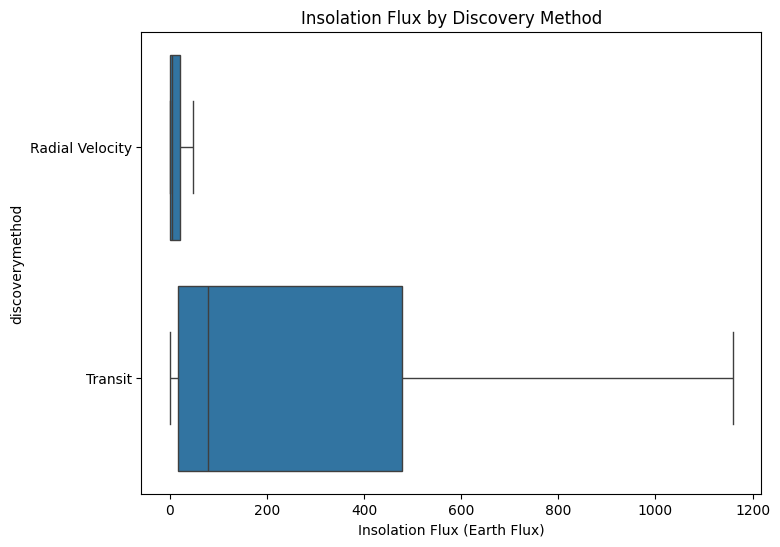

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=filtered, x="pl_insol", y="discoverymethod", showfliers=False, ax=ax
)
ax.set_xlabel("Insolation Flux (Earth Flux)")
ax.set_title("Insolation Flux by Discovery Method")
plt.show()

The linear-scale boxplot compresses most data points near zero because of extreme outliers (hot Jupiters with very high insolation). The log-scale version below reveals the group-level structure more clearly.


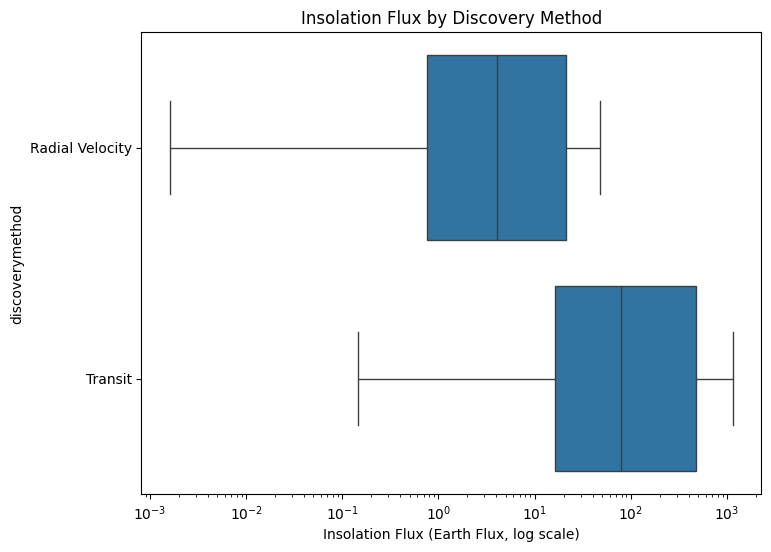

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=filtered, x="pl_insol", y="discoverymethod", showfliers=False, ax=ax
)
ax.set_xscale("log")
ax.set_xlabel("Insolation Flux (Earth Flux, log scale)")
ax.set_title("Insolation Flux by Discovery Method")
plt.show()

### Permutation Test

10,000 simulations to test whether the observed difference in insolation flux between Transit and Radial Velocity planets is due to random chance. We run two versions — one using the difference in means (matching our hypothesis) and one using the difference in medians (robust to the extreme outliers in this dataset).


In [9]:
# Extract groups
transit_insol = filtered[filtered["discoverymethod"] == "Transit"]["pl_insol"]
rv_insol = filtered[filtered["discoverymethod"] == "Radial Velocity"][
    "pl_insol"
]

# Observed test statistic: difference in means (Transit - Radial Velocity)
observed_mean_diff = transit_insol.mean() - rv_insol.mean()
print(f"Observed difference in means (Transit - RV): {observed_mean_diff:.4f}")

# Permutation test: 10,000 simulations
rng = np.random.default_rng(42)
n_simulations = 10_000
perm_mean_diffs = []
combined = filtered["pl_insol"].values.copy()
n_transit = len(transit_insol)

for _ in range(n_simulations):
    rng.shuffle(combined)
    perm_transit = combined[:n_transit]
    perm_rv = combined[n_transit:]
    perm_mean_diffs.append(perm_transit.mean() - perm_rv.mean())

perm_mean_diffs = np.array(perm_mean_diffs)

Observed difference in means (Transit - RV): 452.3525


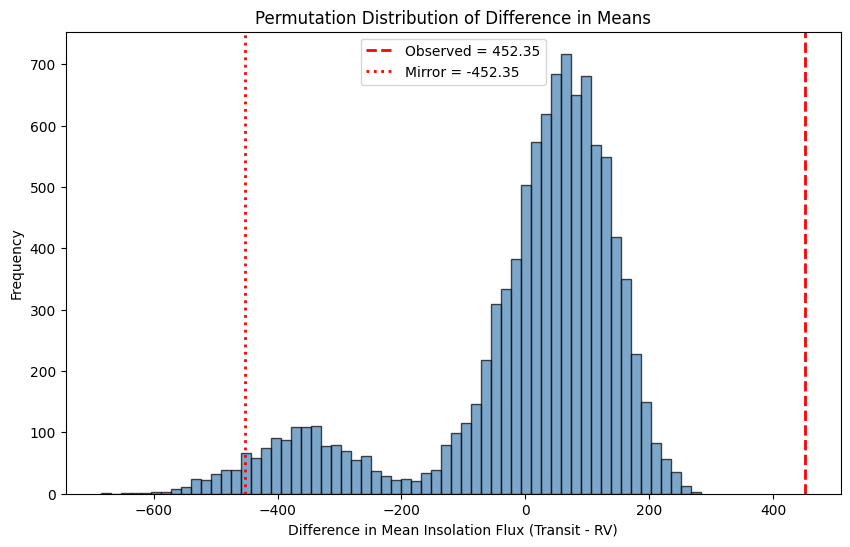

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    perm_mean_diffs, bins=60, edgecolor="black", alpha=0.7, color="steelblue"
)
ax.axvline(
    observed_mean_diff,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Observed = {observed_mean_diff:.2f}",
)
ax.axvline(
    -observed_mean_diff,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Mirror = {-observed_mean_diff:.2f}",
)
ax.set_xlabel("Difference in Mean Insolation Flux (Transit - RV)")
ax.set_ylabel("Frequency")
ax.set_title("Permutation Distribution of Difference in Means")
ax.legend()
plt.show()

In [11]:
mean_p_value = np.mean(np.abs(perm_mean_diffs) >= np.abs(observed_mean_diff))
print(f"Observed difference in means: {observed_mean_diff:.4f}")
print(f"P-value (two-sided): {mean_p_value:.4f}")

Observed difference in means: 452.3525
P-value (two-sided): 0.0212


Note the bimodal shape above: extreme outliers (hot Jupiters) shuffled into the small RV group can spike the group mean, producing a second mode. The median is robust to this, so we also run the permutation test using the difference in medians.


In [12]:
# Observed test statistic: difference in medians (Transit - Radial Velocity)
observed_med_diff = np.median(transit_insol) - np.median(rv_insol)
print(
    f"Observed difference in medians (Transit - RV): {observed_med_diff:.4f}"
)

# Permutation test: 10,000 simulations
rng = np.random.default_rng(42)
n_simulations = 10_000
perm_med_diffs = []
combined = filtered["pl_insol"].values.copy()

for _ in range(n_simulations):
    rng.shuffle(combined)
    perm_transit = combined[:n_transit]
    perm_rv = combined[n_transit:]
    perm_med_diffs.append(np.median(perm_transit) - np.median(perm_rv))

perm_med_diffs = np.array(perm_med_diffs)

Observed difference in medians (Transit - RV): 75.6100


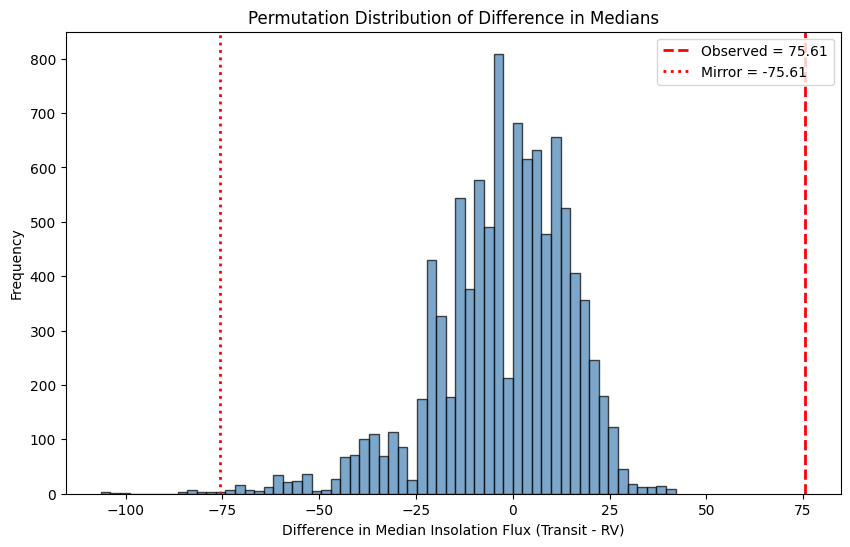

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    perm_med_diffs, bins=60, edgecolor="black", alpha=0.7, color="steelblue"
)
ax.axvline(
    observed_med_diff,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Observed = {observed_med_diff:.2f}",
)
ax.axvline(
    -observed_med_diff,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Mirror = {-observed_med_diff:.2f}",
)
ax.set_xlabel("Difference in Median Insolation Flux (Transit - RV)")
ax.set_ylabel("Frequency")
ax.set_title("Permutation Distribution of Difference in Medians")
ax.legend()
plt.show()

In [14]:
med_p_value = np.mean(np.abs(perm_med_diffs) >= np.abs(observed_med_diff))
print(f"Observed difference in medians: {observed_med_diff:.4f}")
print(f"P-value (two-sided): {med_p_value:.4f}")

Observed difference in medians: 75.6100
P-value (two-sided): 0.0025


### Permutation Test Interpretation

Both permutation tests reject the null hypothesis at α = 0.05. The means-based test shows the difference is statistically significant despite the bimodal null distribution caused by outlier sensitivity. The medians-based test confirms the result with a clean unimodal null distribution, demonstrating that the finding is not driven solely by a handful of extreme hot Jupiters.

The bootstrap confidence intervals below quantify the magnitude of this difference for both the mean and the median.


### Bootstrap Confidence Intervals

To quantify the uncertainty around the observed differences, we use bootstrapping:

1. **Resample with replacement** — for each of 10,000 iterations, independently draw a bootstrap sample (same size as original, with replacement) from both the Transit and RV groups.
2. **Compute the statistic** — calculate the difference in the statistic (mean or median) between the two bootstrap samples.
3. **Build the CI** — use the 2.5th and 97.5th percentiles of the 10,000 bootstrapped differences as the bounds of a 95% confidence interval.

We bootstrap two metrics:

- **Difference in means** — the CLT could apply here in principle, but convergence is slow due to extreme right-skew, making the normal approximation unreliable (especially for the small RV group). Bootstrap sidesteps this assumption.
- **Difference in medians** — the CLT **does not apply** to the median. There is no closed-form standard error for the median of skewed data, so bootstrapping is the standard approach for building confidence intervals around medians.


#### Difference in Means


In [15]:
# Bootstrap the difference in means
n_bootstrap = 10_000
boot_diffs = []

for _ in range(n_bootstrap):
    boot_transit = transit_insol.sample(frac=1, replace=True)
    boot_rv = rv_insol.sample(frac=1, replace=True)
    boot_diffs.append(boot_transit.mean() - boot_rv.mean())

boot_diffs = np.array(boot_diffs)
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print(f"Observed difference in means: {observed_mean_diff:.4f}")
print(f"95% Bootstrap CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Observed difference in means: 452.3525
95% Bootstrap CI: (351.1016, 596.8772)


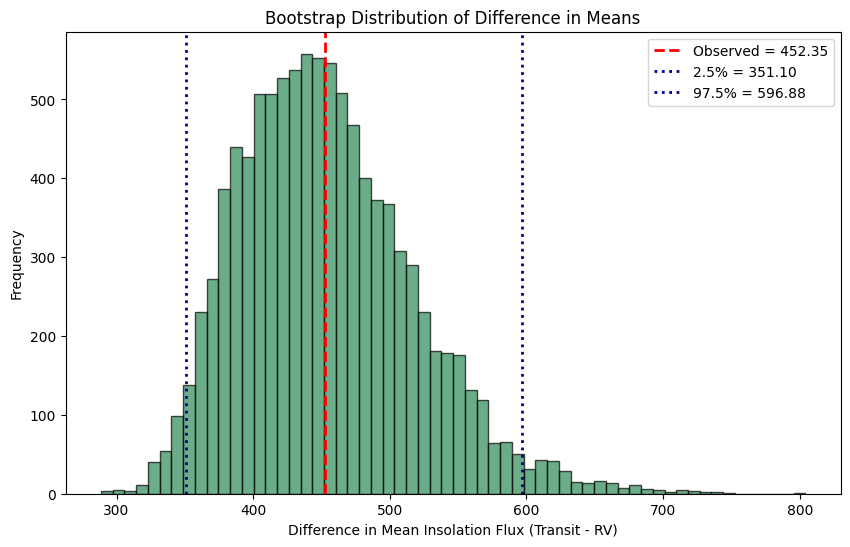

In [16]:
# Histogram of bootstrap distribution with observed difference and CI
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(boot_diffs, bins=60, edgecolor="black", alpha=0.7, color="seagreen")
ax.axvline(
    observed_mean_diff,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Observed = {observed_mean_diff:.2f}",
)
ax.axvline(
    ci_lower,
    color="darkblue",
    linestyle=":",
    linewidth=2,
    label=f"2.5% = {ci_lower:.2f}",
)
ax.axvline(
    ci_upper,
    color="darkblue",
    linestyle=":",
    linewidth=2,
    label=f"97.5% = {ci_upper:.2f}",
)
ax.set_xlabel("Difference in Mean Insolation Flux (Transit - RV)")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of Difference in Means")
ax.legend()
plt.show()

### Bootstrap Mean Interpretation

The 95% bootstrap confidence interval for the difference in means (Transit − RV) does not include zero, reinforcing the permutation test result. We are 95% confident that Transit-detected planets have a higher mean insolation flux than RV-detected planets. The interval gives us a sense of the plausible magnitude of that difference.


#### Difference in Medians


In [17]:
# Bootstrap the difference in medians
n_bootstrap = 10_000
boot_med_diffs = []

for _ in range(n_bootstrap):
    boot_transit = transit_insol.sample(frac=1, replace=True)
    boot_rv = rv_insol.sample(frac=1, replace=True)
    boot_med_diffs.append(boot_transit.median() - boot_rv.median())

boot_med_diffs = np.array(boot_med_diffs)
med_ci_lower = np.percentile(boot_med_diffs, 2.5)
med_ci_upper = np.percentile(boot_med_diffs, 97.5)
observed_med_diff = transit_insol.median() - rv_insol.median()

print(f"Observed difference in medians: {observed_med_diff:.4f}")
print(
    f"95% Bootstrap CI for median difference: ({med_ci_lower:.4f}, {med_ci_upper:.4f})"
)

Observed difference in medians: 75.6100
95% Bootstrap CI for median difference: (62.3000, 96.5600)


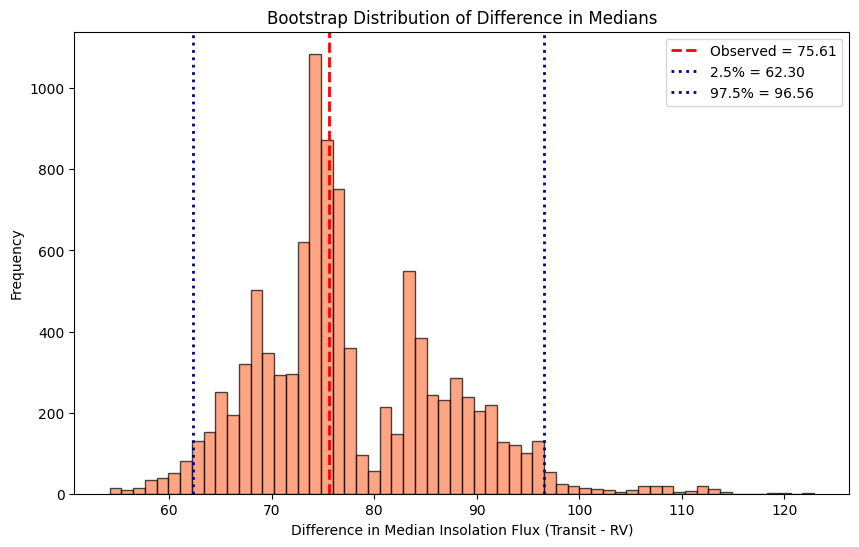

In [18]:
# Histogram of bootstrap distribution for median difference
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(boot_med_diffs, bins=60, edgecolor="black", alpha=0.7, color="coral")
ax.axvline(
    observed_med_diff,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Observed = {observed_med_diff:.2f}",
)
ax.axvline(
    med_ci_lower,
    color="darkblue",
    linestyle=":",
    linewidth=2,
    label=f"2.5% = {med_ci_lower:.2f}",
)
ax.axvline(
    med_ci_upper,
    color="darkblue",
    linestyle=":",
    linewidth=2,
    label=f"97.5% = {med_ci_upper:.2f}",
)
ax.set_xlabel("Difference in Median Insolation Flux (Transit - RV)")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of Difference in Medians")
ax.legend()
plt.show()

### Bootstrap Median Interpretation

The median is more robust to extreme outliers than the mean. The 95% CI for the difference in medians also excludes zero, confirming that the shift is not driven solely by a handful of extreme hot Jupiters — the typical Transit planet receives meaningfully more stellar flux than the typical RV planet.


### Central Limit Theorem Demonstration

The CLT says the sampling distribution of the mean approaches normality as sample size grows — regardless of the underlying distribution. The panels below show this in action for Transit insolation flux: the raw data is extremely right-skewed, but sample means become progressively more bell-shaped as n increases.

The key insight is **how slowly** convergence happens with this level of skewness. At n = 50 or even n = 200, the sampling distribution is still visibly non-normal. This is why we used bootstrapping rather than relying on CLT-based confidence intervals — with extreme skew we cannot be sure "large enough" n has been reached, and for the median, the CLT does not apply at all.


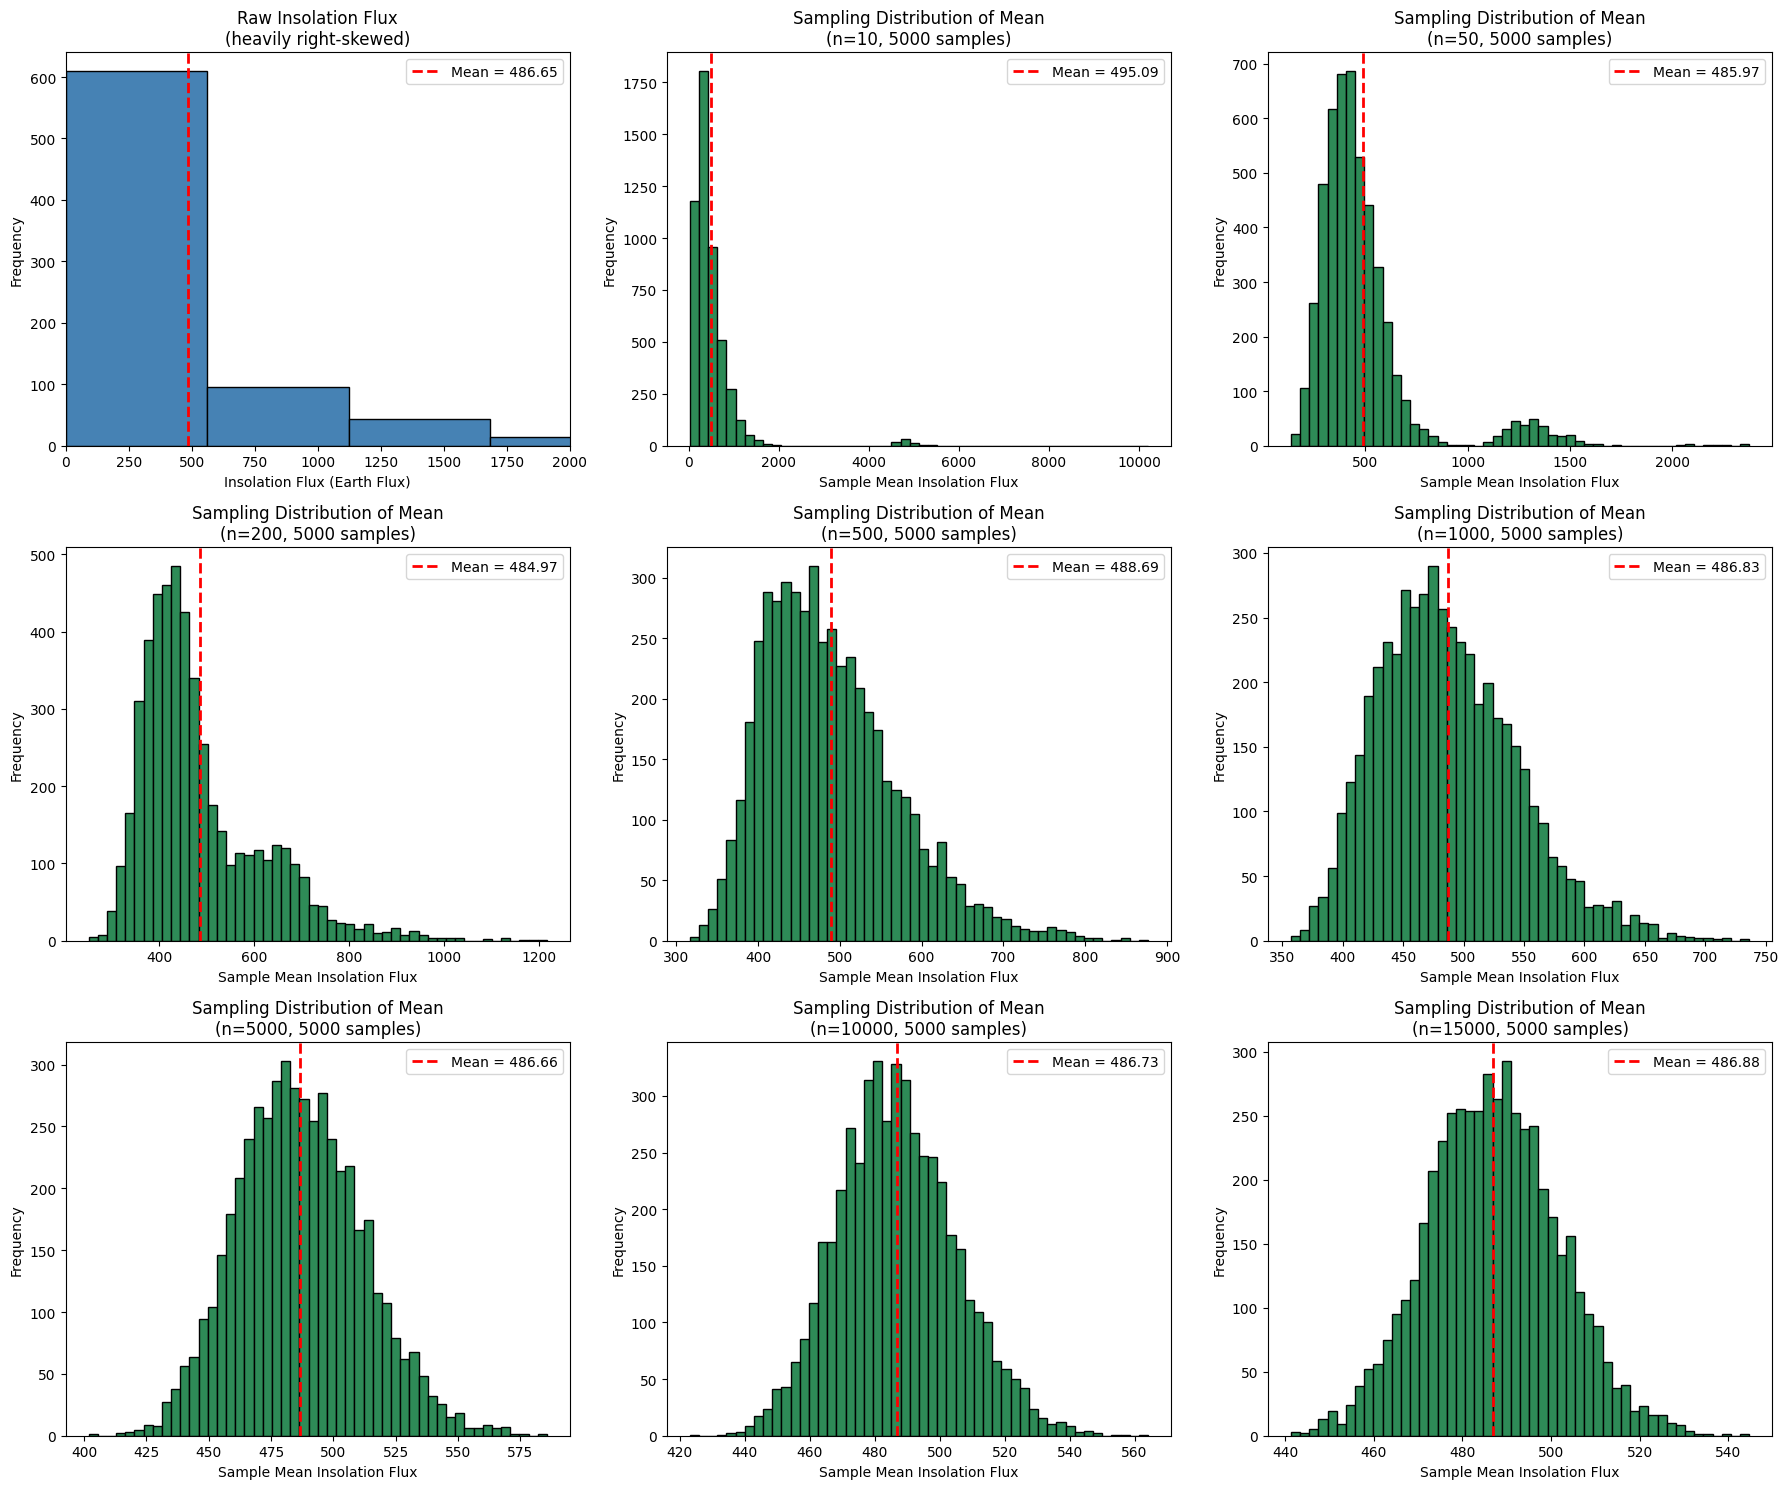

In [19]:
# Demonstrate CLT: sampling distribution of the mean becomes normal
# even though the underlying data is heavily skewed

transit_vals = transit_insol.values
true_mean = transit_vals.mean()

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Panel 0: Raw distribution (heavily skewed)
axes[0].hist(transit_vals, bins=80, color="steelblue", edgecolor="black")
axes[0].axvline(
    true_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {true_mean:.2f}",
)
axes[0].set_xlim(
    0, 2000
)  # cap for visibility — extreme hot Jupiters extend much further
axes[0].set_title("Raw Insolation Flux\n(heavily right-skewed)")
axes[0].set_xlabel("Insolation Flux (Earth Flux)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Panels 1-8: Sampling distributions of the mean for increasing n
sample_sizes = [10, 50, 200, 500, 1000, 5000, 10000, 15000]
n_samples = 5000
rng = np.random.default_rng(42)

for ax, n in zip(axes[1:], sample_sizes):
    sample_means = rng.choice(
        transit_vals, size=(n_samples, n), replace=True
    ).mean(axis=1)
    mean_of_means = sample_means.mean()

    ax.hist(sample_means, bins=50, color="seagreen", edgecolor="black")
    ax.axvline(
        mean_of_means,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_of_means:.2f}",
    )
    ax.set_title(
        f"Sampling Distribution of Mean\n(n={n}, {n_samples} samples)"
    )
    ax.set_xlabel("Sample Mean Insolation Flux")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

### CLT Takeaway

The demonstration above confirms that the CLT does eventually produce a normal sampling distribution for the mean — but convergence is slow for heavily skewed data. At moderate sample sizes the distribution still shows visible right-skew. For our analysis this matters because:

1. **The RV group is small** — CLT convergence is unreliable for its mean.
2. **The median has no CLT analog** — there is no closed-form standard error for the median of skewed data.
3. **Bootstrapping works regardless** — it directly estimates the sampling distribution without assuming normality, making it the safer and more general choice.


### Conclusion

The evidence consistently points to a significant difference in insolation flux between Transit- and Radial Velocity-detected exoplanets:

- **Permutation test:** p = 0.0025 — we reject the null hypothesis at α = 0.05.
- **Bootstrap CI for difference in means:** (349, 598) Earth flux — does not include zero.
- **Bootstrap CI for difference in medians:** (62, 97) Earth flux — does not include zero.

Transit surveys preferentially detect planets receiving more stellar radiation than those found by Radial Velocity. This likely reflects observational bias: transit detection favors short-period, close-in orbits (which receive more flux), while RV is less constrained by orbital period and can detect planets farther from their host stars.

This matters for habitability research — if we rely primarily on transit catalogs to identify "Earth-like" worlds, we are systematically overrepresenting planets in high-insolation environments. Our picture of where potentially habitable planets exist is shaped as much by how we look as by what is actually out there.
